In [1]:
!pip install -q ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")

In [13]:
from ucimlrepo import fetch_ucirepo

banknote = fetch_ucirepo(id=267)
X_raw = banknote.data.features
y_raw = banknote.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
df.columns = ["variance", "skewness", "curtosis", "entropy", "class"]

print("First 5 samples:")
display(df.head())

print("\nDataset dimensions:", df.shape)

print("\nMissing values per column:")
display(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe())

First 5 samples:


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0



Dataset dimensions: (1372, 5)

Missing values per column:


,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0



Descriptive statistics:


,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


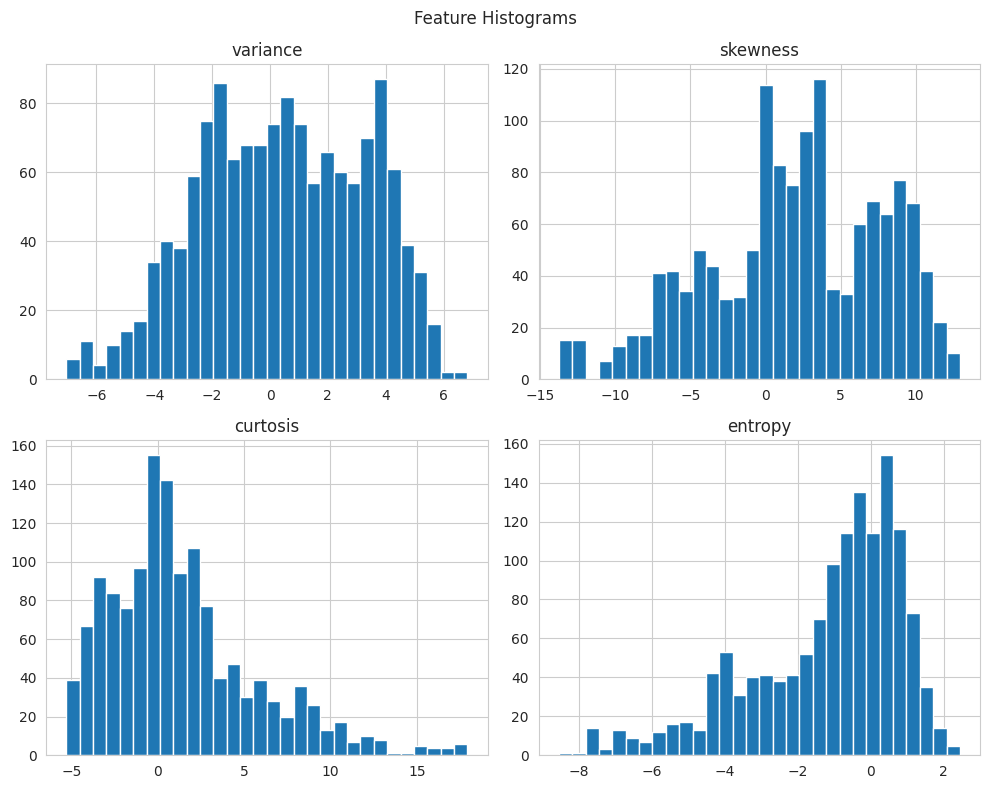

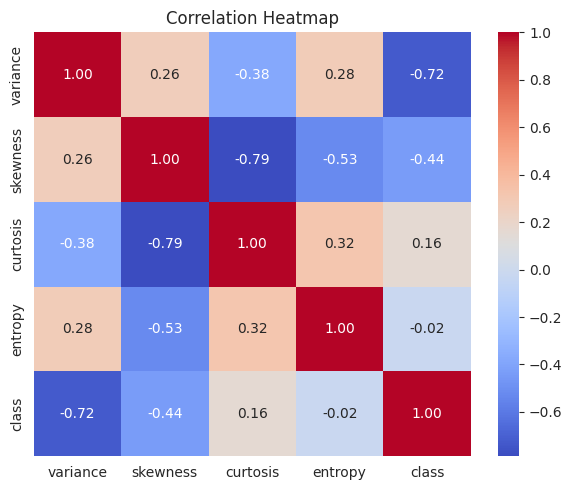

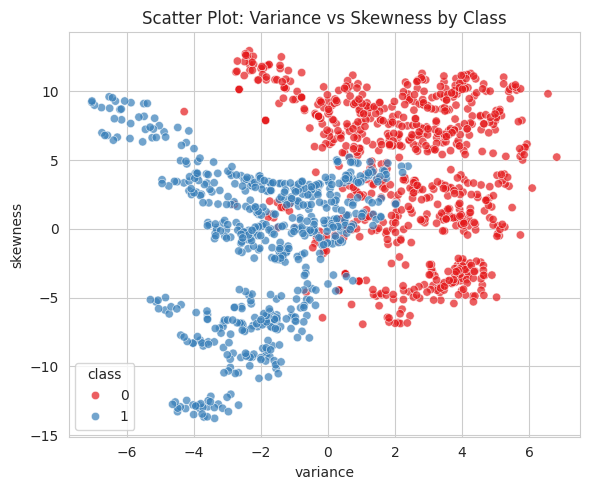

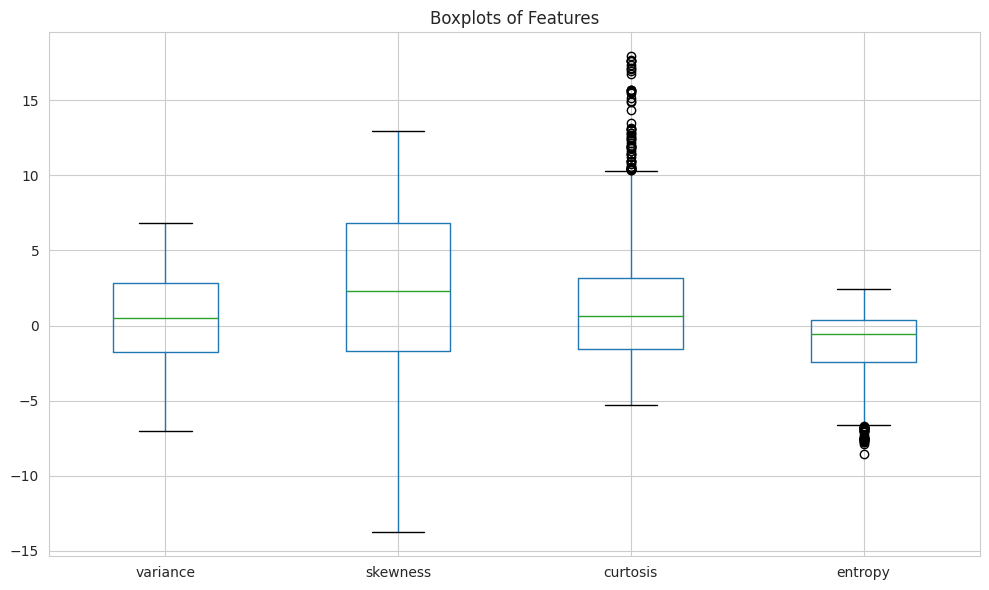

In [3]:
feature_cols = ["variance", "skewness", "curtosis", "entropy"]

# Histograms
df[feature_cols].hist(bins=30, figsize=(10, 8))
plt.suptitle("Feature Histograms")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter plot (variance vs skewness, colored by class)
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="variance", y="skewness", hue="class", palette="Set1", alpha=0.7)
plt.title("Scatter Plot: Variance vs Skewness by Class")
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(10, 6))
df[feature_cols].boxplot()
plt.title("Boxplots of Features")
plt.tight_layout()
plt.show()

In [4]:
X = df[feature_cols].values
y = df["class"].values.ravel().astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 1097
Test set size: 275


In [5]:
class Perceptron:
    def __init__(self, n_features, learning_rate=0.01, n_epochs=50, random_state=42):
        rng = np.random.default_rng(random_state)
        self.weights = rng.normal(0, 0.01, n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.history = []  # per-epoch: epoch, misclassified, weights, bias

    @staticmethod
    def step_activation(z):
        return np.where(z >= 0, 1, 0)

    def forward(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.step_activation(z)

    def fit(self, X, y, verbose=True):
        for epoch in range(1, self.n_epochs + 1):
            misclassified = 0
            for xi, yi in zip(X, y):
                z = np.dot(xi, self.weights) + self.bias
                y_hat = self.step_activation(z)
                error = yi - y_hat
                if error != 0:
                    misclassified += 1
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error

            self.history.append({
                "epoch": epoch,
                "misclassified": misclassified,
                "weights": self.weights.copy(),
                "bias": self.bias
            })

            if verbose:
                print(f"Epoch {epoch:3d} | Misclassified: {misclassified:4d} | "
                      f"Weights: {np.round(self.weights, 4)} | Bias: {self.bias:.4f}")

            if misclassified == 0:
                print(f"Converged at epoch {epoch}.")
                break
        return self

    def predict(self, X):
        return self.forward(X)

In [6]:
default_lr = 0.01
model = Perceptron(n_features=X_train.shape[1], learning_rate=default_lr, n_epochs=50,
                    random_state=RANDOM_STATE)
model.fit(X_train, y_train)

Epoch   1 | Misclassified:   51 | Weights: [-0.0626 -0.0793 -0.0635 -0.0028] | Bias: -0.0300
Epoch   2 | Misclassified:   24 | Weights: [-0.0762 -0.1023 -0.0646 -0.0003] | Bias: -0.0300
Epoch   3 | Misclassified:   23 | Weights: [-0.078  -0.0965 -0.0914 -0.0022] | Bias: -0.0400
Epoch   4 | Misclassified:   32 | Weights: [-0.0886 -0.1127 -0.098  -0.0056] | Bias: -0.0600
Epoch   5 | Misclassified:   26 | Weights: [-0.0967 -0.1214 -0.1062 -0.0061] | Bias: -0.0600
Epoch   6 | Misclassified:   20 | Weights: [-0.1096 -0.1347 -0.104  -0.0023] | Bias: -0.0400
Epoch   7 | Misclassified:   23 | Weights: [-0.1161 -0.1428 -0.1101 -0.0042] | Bias: -0.0500
Epoch   8 | Misclassified:   20 | Weights: [-0.1059 -0.1432 -0.1247 -0.0002] | Bias: -0.0700
Epoch   9 | Misclassified:   23 | Weights: [-0.1249 -0.1533 -0.1172  0.0035] | Bias: -0.0600
Epoch  10 | Misclassified:   18 | Weights: [-0.1199 -0.1608 -0.1236  0.0092] | Bias: -0.0600
Epoch  11 | Misclassified:   17 | Weights: [-0.1248 -0.1561 -0.1333  0

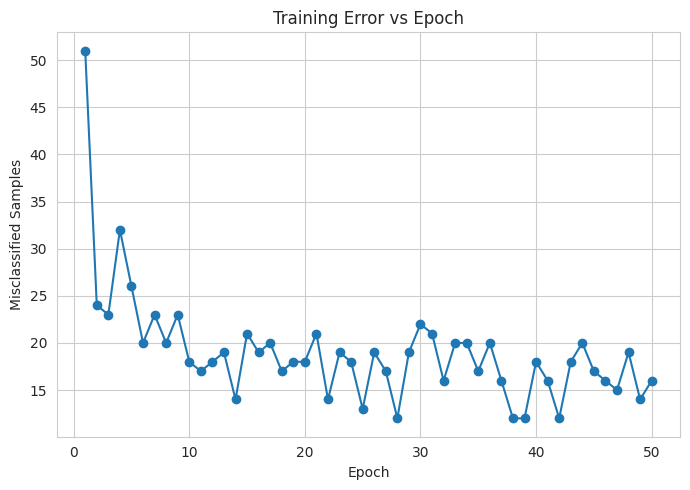

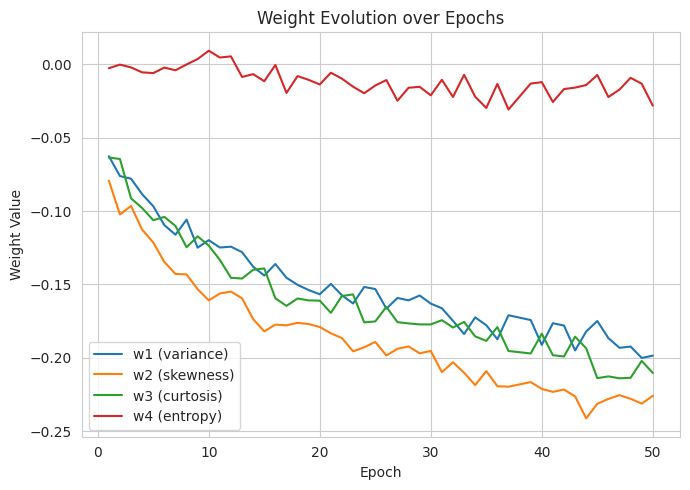

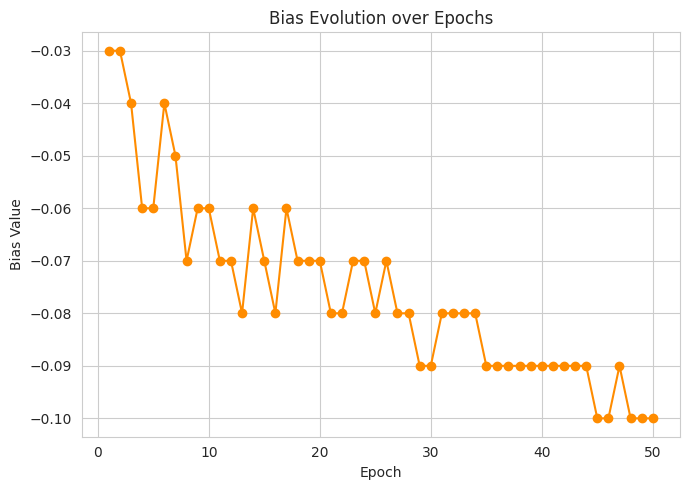

In [7]:
epochs = [h["epoch"] for h in model.history]
errors = [h["misclassified"] for h in model.history]
weights_hist = np.array([h["weights"] for h in model.history])
bias_hist = [h["bias"] for h in model.history]

# Training error vs epoch
plt.figure(figsize=(7, 5))
plt.plot(epochs, errors, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()

# Weight evolution
plt.figure(figsize=(7, 5))
for i in range(weights_hist.shape[1]):
    plt.plot(epochs, weights_hist[:, i], label=f"w{i+1} ({feature_cols[i]})")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Bias evolution
plt.figure(figsize=(7, 5))
plt.plot(epochs, bias_hist, marker="o", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.title("Bias Evolution over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

Accuracy : 0.9891
Precision: 0.9837
Recall   : 0.9918
F1-score : 0.9878


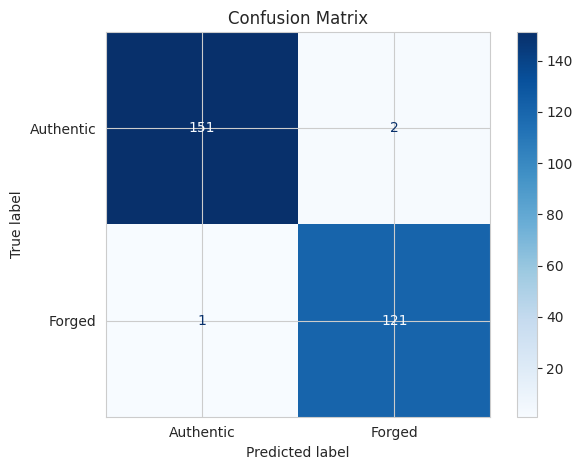

In [8]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Authentic", "Forged"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

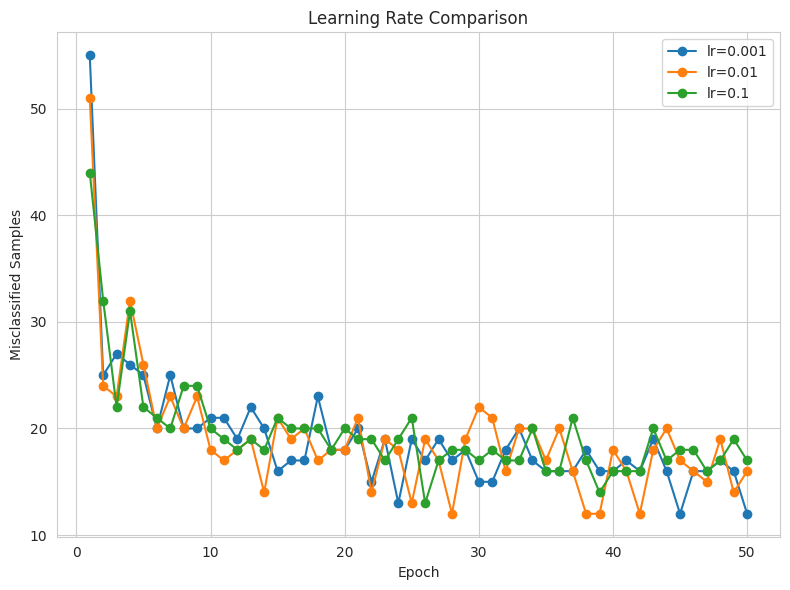

Learning Rate Comparison:
LR=0.001: Accuracy=0.9782, F1=0.9758, Epochs to converge=50
LR=0.01: Accuracy=0.9891, F1=0.9878, Epochs to converge=50
LR=0.1: Accuracy=0.9818, F1=0.9799, Epochs to converge=50


In [9]:
learning_rates = [0.001, 0.01, 0.1]
lr_results = {}

plt.figure(figsize=(8, 6))
for lr in learning_rates:
    m = Perceptron(n_features=X_train.shape[1], learning_rate=lr, n_epochs=50,
                    random_state=RANDOM_STATE)
    m.fit(X_train, y_train, verbose=False)
    errs = [h["misclassified"] for h in m.history]
    eps = [h["epoch"] for h in m.history]
    plt.plot(eps, errs, marker="o", label=f"lr={lr}")

    y_pred_lr = m.predict(X_test)
    lr_results[lr] = {
        "accuracy": accuracy_score(y_test, y_pred_lr),
        "precision": precision_score(y_test, y_pred_lr),
        "recall": recall_score(y_test, y_pred_lr),
        "f1": f1_score(y_test, y_pred_lr),
        "final_weights": m.weights,
        "final_bias": m.bias,
        "epochs_to_converge": len(m.history)
    }

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Learning Rate Comparison:")
for lr, res in lr_results.items():
    print(f"LR={lr}: Accuracy={res['accuracy']:.4f}, F1={res['f1']:.4f}, "
          f"Epochs to converge={res['epochs_to_converge']}")

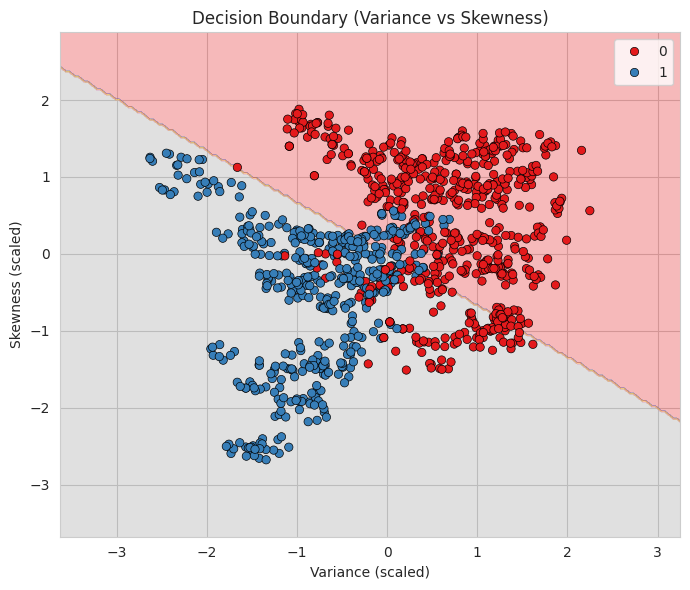

In [10]:
X_2d = X_train[:, :2]  # variance, skewness
model_2d = Perceptron(n_features=2, learning_rate=default_lr, n_epochs=50,
                       random_state=RANDOM_STATE)
model_2d.fit(X_2d, y_train, verbose=False)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="Set1")
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y_train, palette="Set1", edgecolor="k")
plt.xlabel("Variance (scaled)")
plt.ylabel("Skewness (scaled)")
plt.title("Decision Boundary (Variance vs Skewness)")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.linear_model import Perceptron as SklearnPerceptron

sk_model = SklearnPerceptron(eta0=default_lr, max_iter=50, random_state=RANDOM_STATE)
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)

print(f"Scratch Accuracy  : {accuracy:.4f} | Sklearn Accuracy  : {accuracy_score(y_test, y_pred_sk):.4f}")
print(f"Scratch F1-score  : {f1:.4f} | Sklearn F1-score  : {f1_score(y_test, y_pred_sk):.4f}")

Scratch Accuracy  : 0.9891 | Sklearn Accuracy  : 0.9745
Scratch F1-score  : 0.9878 | Sklearn F1-score  : 0.9721


In [12]:
summary = pd.DataFrame({
    "Metric": ["Dataset Size", "Train/Test Split", "Learning Rate", "Epochs Run",
               "Final Weights", "Final Bias", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [len(df), "80/20", default_lr, len(model.history),
              np.round(model.weights, 4), round(model.bias, 4),
              round(accuracy, 4), round(precision, 4), round(recall, 4), round(f1, 4)]
})
print("Training Summary:")
display(summary)

epochwise = pd.DataFrame({
    "Epoch": epochs,
    "Errors": errors,
    "Weight 1": weights_hist[:, 0],
    "Weight 2": weights_hist[:, 1],
    "Bias": bias_hist
})
print("\nEpoch-wise Learning:")
display(epochwise)

Training Summary:


,Metric,Value
0,Dataset Size,1372
1,Train/Test Split,80/20
2,Learning Rate,0.01
3,Epochs Run,50
4,Final Weights,"[-0.1985, -0.2258, -0.2102, -0.0282]"
5,Final Bias,-0.1
6,Accuracy,0.9891
7,Precision,0.9837
8,Recall,0.9918
9,F1-score,0.9878



Epoch-wise Learning:


,Epoch,Errors,Weight 1,Weight 2,Bias
0,1,51,-0.062639,-0.079346,-0.03
1,2,24,-0.076201,-0.102321,-0.03
2,3,23,-0.078001,-0.096537,-0.04
3,4,32,-0.088552,-0.112673,-0.06
4,5,26,-0.096734,-0.121424,-0.06
5,6,20,-0.109605,-0.134685,-0.04
6,7,23,-0.116120,-0.142836,-0.05
7,8,20,-0.105867,-0.143171,-0.07
8,9,23,-0.124937,-0.153265,-0.06
9,10,18,-0.119858,-0.160837,-0.06
